# Linear Regression: Model Building and Assumption Checking

This notebook demonstrates how to build a Multiple Linear Regression model
and verify the major assumptions of linear regression.

## 1. Assumptions of Linear Regression

Before interpreting a linear regression model, we should check whether the
main assumptions of linear regression are reasonably satisfied.

The major assumptions are:

1. Linear relationship between predictors and target
2. No multicollinearity among predictors
3. Normality of residuals
4. Homoscedasticity of residuals
5. No autocorrelation of errors

### 1.1 Linear Relationship

There should be an approximately linear relationship between the predictors
and the target variable.

### 1.2 No Multicollinearity

The independent variables should not be highly correlated with each other.
High multicollinearity can make regression coefficients unstable.

### 1.3 Normality of Residuals

The residuals should be approximately normally distributed, particularly
for reliable statistical inference.

### 1.4 Homoscedasticity

The variance of residuals should remain approximately constant across
different levels of predicted values.

### 1.5 No Autocorrelation

The residuals should be independent of each other. This is particularly
important for time-series or sequential data.

## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Load the Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Niloy\Downloads\ml practice\Diabetes.csv")

In [3]:
df

,BMI,BP,Cholesterol,LDL,Target
0,26,99,165,75,524
1,39,65,285,92,717
2,34,70,226,77,655
3,31,114,274,63,732
4,21,96,198,68,606
...,...,...,...,...,...
195,26,116,221,181,784
196,34,112,250,190,902
197,38,86,176,135,703
198,38,105,179,154,747


### 3.1 Dataset Columns

In [4]:
df.columns

Index(['BMI', 'BP', 'Cholesterol', 'LDL', 'Target'], dtype='str')

## 4. Checking Assumption 1: Linearity

A scatter plot is used to visually examine the relationship between each
predictor and the target variable.

An approximately straight-line pattern supports the linearity assumption.

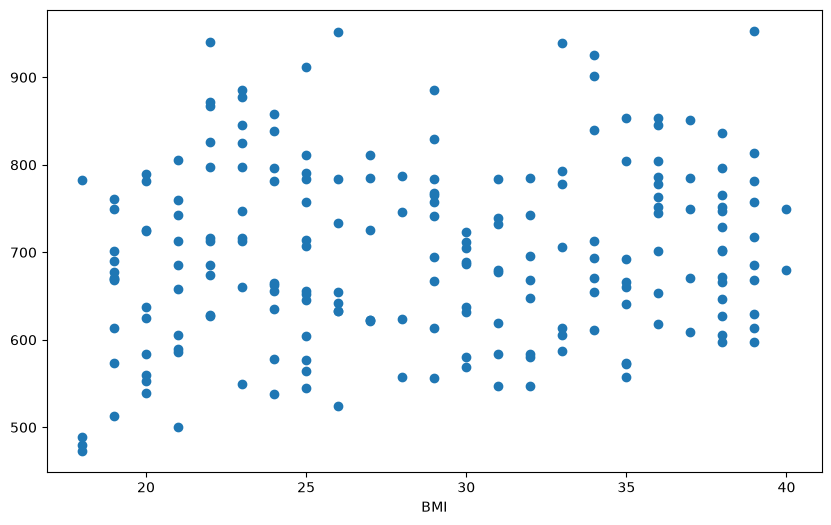

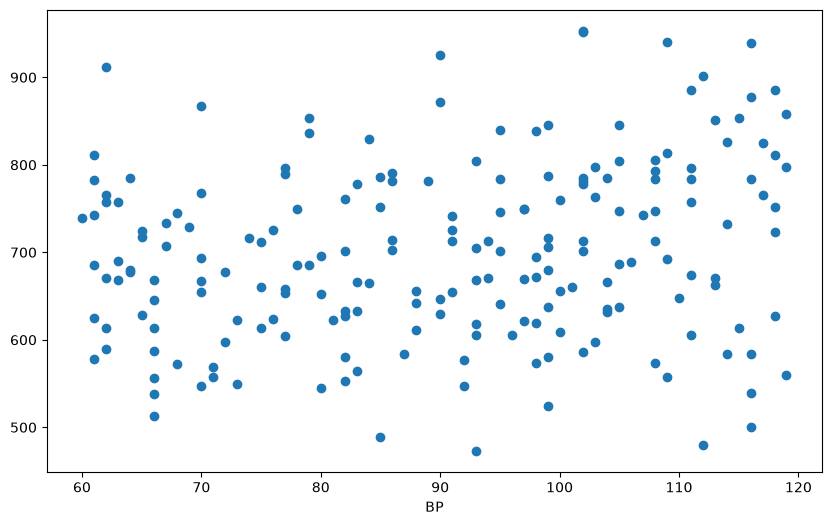

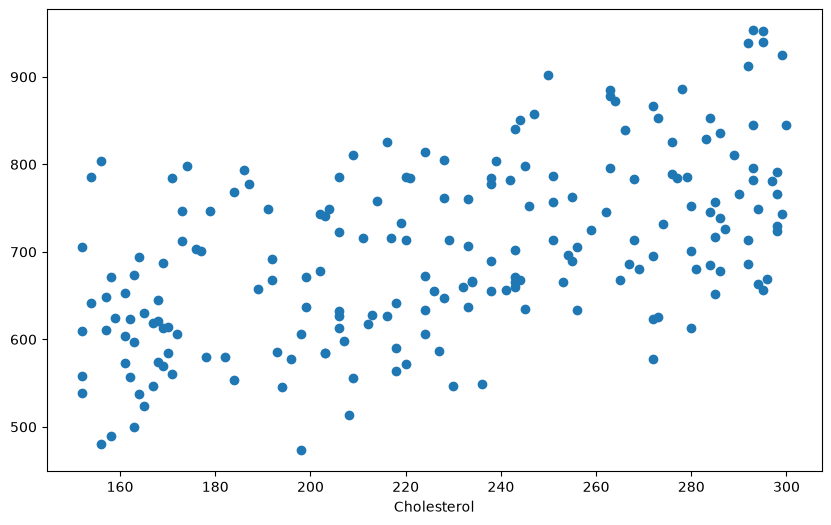

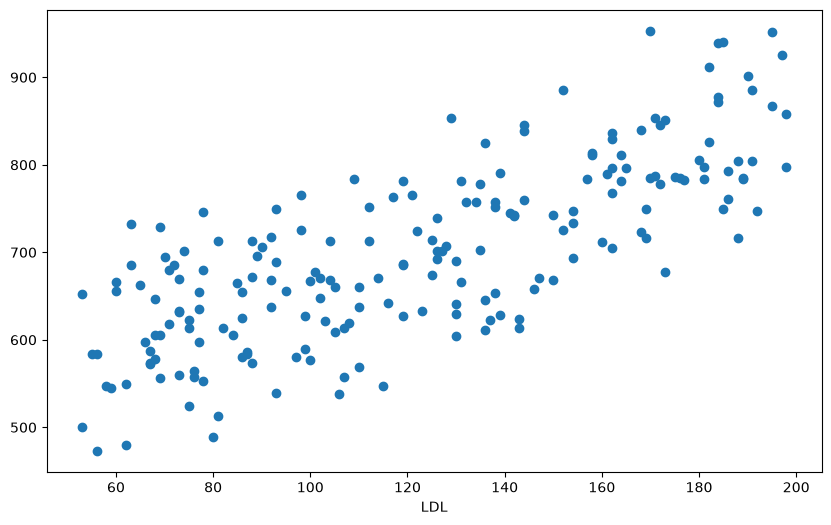

In [5]:
features = ['BMI', 'BP', 'Cholesterol', 'LDL']
i=0
for col in features:
    plt.figure(figsize=(10,6))
    plt.scatter(df[col],df['Target'])
    plt.xlabel(features[i])
    plt.show()
    i+=1

In [6]:
from sklearn.model_selection import train_test_split
X=df.drop("Target",axis=1)
y=df['Target']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 5. Checking Assumption 2: No Multicollinearity

Multicollinearity occurs when two or more independent variables are highly
correlated with each other.

Variance Inflation Factor (VIF) is used to quantify multicollinearity.

### VIF Interpretation

| VIF | Interpretation |
|---:|---|
| 1 | No multicollinearity |
| 1–5 | Usually acceptable |
| 5–10 | High; investigate |
| >10 | Serious multicollinearity |

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x=df[['BMI', 'BP', 'Cholesterol', 'LDL']]
vif = pd.DataFrame()

vif['Feature'] = x.columns

vif['VIF'] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

print(vif)

       Feature       VIF
0          BMI  1.003990
1           BP  1.023363
2  Cholesterol  1.023741
3          LDL  1.010567


In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[2.79,1.27,1.2 ,1.74]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['BMI','BP','Cholesterol','LDL']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,18.47
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [10]:
y_pred = lr.predict(X_test)

## 6. Checking Assumption 3: Normality of Residuals

The distribution of residuals is examined using a histogram and KDE curve.

If the residuals are approximately bell-shaped and symmetric around zero,
the normality assumption is reasonably supported.

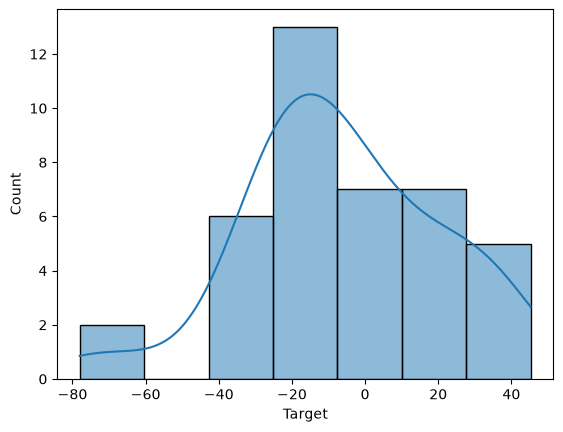

In [11]:
import seaborn as sns
residual = y_pred - y_test
sns.histplot(residual,kde=True)
plt.show()

## 7. Checking Assumption 4: Homoscedasticity

Homoscedasticity means that the variance of residuals remains approximately
constant across different predicted values.

A residual-vs-predicted plot is used to examine this assumption.

Ideally, the residuals should be randomly scattered around zero with
approximately constant spread.

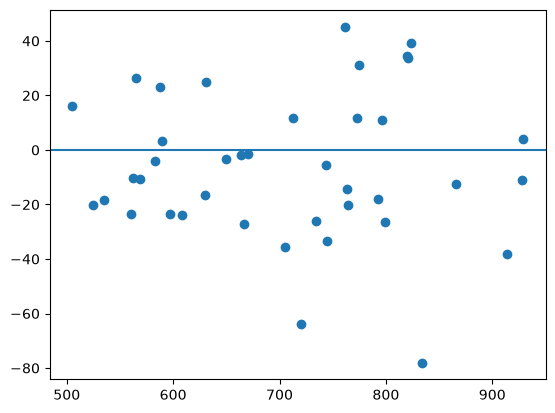

In [12]:
plt.scatter(y_pred,residual)
plt.axhline(y=0)
plt.show()

## 8. Checking Assumption 5: No Autocorrelation

Autocorrelation occurs when residuals are correlated with one another.

A residual sequence plot can be used to visually inspect whether the residuals
show systematic patterns.

For independent errors, residuals should fluctuate randomly around zero
without a clear pattern.

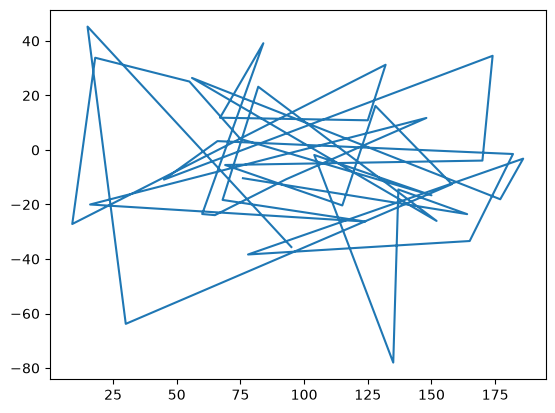

In [13]:
plt.plot(residual)
plt.show()